In [1]:
import numpy as np
import pandas as pd
import time

import seaborn as sns
import matplotlib.pyplot as plt

from utils.label_query import query_labels
from utils.result_plotter import plot_ssalad_results
from utils.semi_supervised_trainer import run_experiment


In [ ]:
"""
label_prop_time = Time take to do label propagation. It does not include training the detection models.
time = time taken to train  and infer from either supervised (xgboost where we checking what eefect does increasing estimators has) and nsupervised (iforest)
"""

In [19]:
# # curr_fractions = [0, 0.001, 0.002, 0.004, 0.006, 0.008, 0.01, 0.013, 0.02, 0.03, 0.04, 0.06, 0.08, 0.1, 0.15, 0.2, 0.3, 0.45, 0.7, 1.0]
# curr_fractions = [0.0, 0.0042, 0.001,0.01, 0.013, 0.04, 0.06, 0.08, 0.1, 0.15, 0.35, 0.5, 0.7]
# all_models = ['IForest']
# final_results = pd.DataFrame()
# all_datasets = ['11_donors', '33_skin', '26_optdigits', '45_wine', '12_fault', '30_satellite', '37_Stamps']
# for each_data in all_datasets:
#     path = f'data/{each_data}.npz'
#     data = np.load(path, allow_pickle=True)
#     X, y = data['X'], data['y']
    
#     for each_neighbour in [5,10,15,20,25,30,35,40]:
#         for each_estimator in [20,50,100,150,200,300,400,500,1000]:
#             results = run_experiment(
#                 X = X, y = y, 
#                 fractions=curr_fractions, 
#                 dataset_name=each_data,
#                 num_samples=2000,
#                 reps=3, 
#                 model_names=all_models,
#                 query_strategies = ['clusters', 'uncertainty'], #,'random', "anomalous"],
#                 propagations = [True],# False],
#                 kernel="knn",
#                 params={
#                     "n_neighbors": each_neighbour, 
#                      "estimators": each_estimator,
#                 }
#             )
#             final_results = pd.concat([final_results, results]).reset_index(drop=True)


In [4]:
final_results

,dataset,num_samples,model,fraction,rep,query_strategy,propagation,kernel,num_labels,label_prop_time,estimators,n_neighbors,roc_auc,time
0,11_donors,2001,IForest,0.0,0,clusters,True,knn,0,0.000000,20,5,0.759316,0.244782
1,11_donors,2001,IForest,0.0,1,clusters,True,knn,0,0.000000,20,5,0.793110,0.225753
2,11_donors,2001,IForest,0.0,2,clusters,True,knn,0,0.000000,20,5,0.765108,0.287300
3,11_donors,2001,IForest,0.0,0,uncertainty,True,knn,0,0.000000,20,5,0.800195,0.195513
4,11_donors,2001,IForest,0.0,1,uncertainty,True,knn,0,0.000000,20,5,0.756837,0.194143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,11_donors,1995,XGB,0.7,0,uncertainty,True,knn,700,0.354675,20,5,1.000000,0.015933
130,11_donors,2001,IForest,0.7,1,uncertainty,True,knn,700,0.357879,20,5,0.879224,0.177352
131,11_donors,1996,XGB,0.7,1,uncertainty,True,knn,700,0.357879,20,5,1.000000,0.018864
132,11_donors,2001,IForest,0.7,2,uncertainty,True,knn,700,0.356457,20,5,0.895306,0.182649


In [22]:
# final_results.to_csv("parameter_testing_results.csv", index=False)

In [23]:
final_results = pd.read_csv("parameter_testing_results.csv")

In [24]:
final_results["n_neighbors"].unique()

array([ 5, 10, 15, 20, 25, 30, 35, 40])

In [25]:
final_results.shape

(67448, 14)

In [26]:
final_results

,dataset,num_samples,model,fraction,rep,query_strategy,propagation,kernel,num_labels,label_prop_time,estimators,n_neighbors,roc_auc,time
0,11_donors,2001,IForest,0.0,0,clusters,True,knn,0,0.000000,20,5,0.791817,0.252198
1,11_donors,2001,IForest,0.0,1,clusters,True,knn,0,0.000000,20,5,0.776780,0.247518
2,11_donors,2001,IForest,0.0,2,clusters,True,knn,0,0.000000,20,5,0.743146,0.240418
3,11_donors,2001,IForest,0.0,0,uncertainty,True,knn,0,0.000000,20,5,0.793181,0.240677
4,11_donors,2001,IForest,0.0,1,uncertainty,True,knn,0,0.000000,20,5,0.749274,0.241341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67443,37_Stamps,340,XGB,0.7,0,uncertainty,True,knn,118,0.178910,1000,40,0.895269,0.202621
67444,37_Stamps,340,IForest,0.7,1,uncertainty,True,knn,118,0.182634,1000,40,0.953328,0.153108
67445,37_Stamps,340,XGB,0.7,1,uncertainty,True,knn,118,0.182634,1000,40,0.852881,0.180428
67446,37_Stamps,340,IForest,0.7,2,uncertainty,True,knn,118,0.192506,1000,40,0.920860,0.187708


In [27]:
final_results.columns

Index(['dataset', 'num_samples', 'model', 'fraction', 'rep', 'query_strategy',
       'propagation', 'kernel', 'num_labels', 'label_prop_time', 'estimators',
       'n_neighbors', 'roc_auc', 'time'],
      dtype='object')

In [10]:
df = final_results.copy()

In [28]:
for in_data in final_results["dataset"].unique():
    path = f'data/{in_data}.npz'
    data = np.load(path, allow_pickle=True)
    X, y = data['X'], data['y']
    
    print(f"{in_data}= {X.shape}")

11_donors= (619326, 10)
33_skin= (245057, 3)
26_optdigits= (5216, 64)
45_wine= (129, 13)
12_fault= (1941, 27)
30_satellite= (6435, 36)
37_Stamps= (340, 9)


In [33]:
xgb = final_results[(final_results.model == "XGB")].reset_index(drop=True)
iforest = final_results[(final_results.model != "XGB")].reset_index(drop=True)

In [34]:
iforest.head()

,dataset,num_samples,model,fraction,rep,query_strategy,propagation,kernel,num_labels,label_prop_time,estimators,n_neighbors,roc_auc,time
0,11_donors,2001,IForest,0.0,0,clusters,True,knn,0,0.0,20,5,0.791817,0.252198
1,11_donors,2001,IForest,0.0,1,clusters,True,knn,0,0.0,20,5,0.776780,0.247518
2,11_donors,2001,IForest,0.0,2,clusters,True,knn,0,0.0,20,5,0.743146,0.240418
3,11_donors,2001,IForest,0.0,0,uncertainty,True,knn,0,0.0,20,5,0.793181,0.240677
4,11_donors,2001,IForest,0.0,1,uncertainty,True,knn,0,0.0,20,5,0.749274,0.241341


In [35]:
# #drop model columns, and kernel, propagation, rep
iforest = iforest.drop(columns=["model", "rep", "propagation", "kernel"])
xgb = xgb.drop(columns=[ "model", "rep", "propagation", "kernel"])

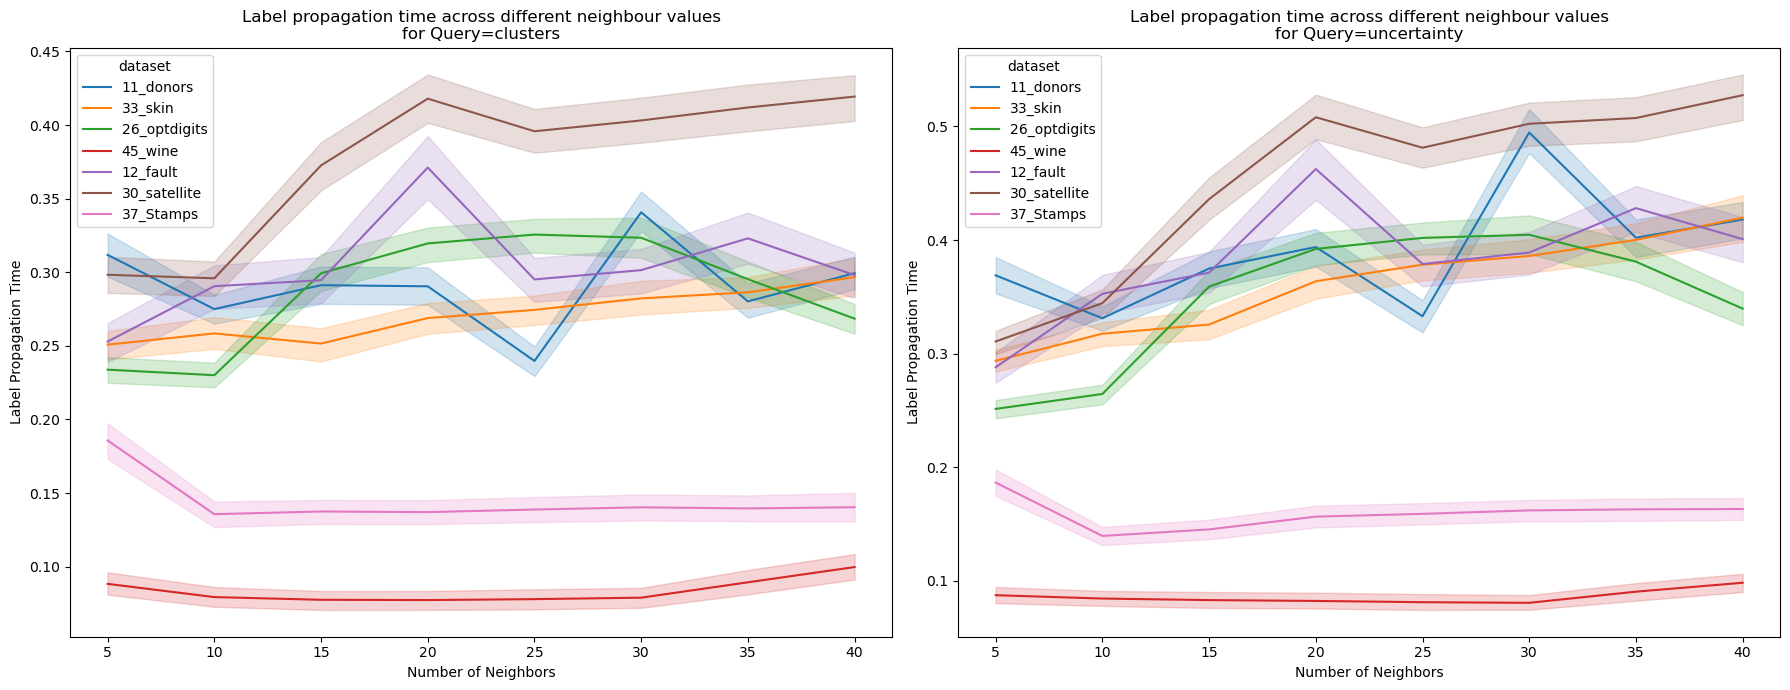

In [39]:
queries = iforest.query_strategy.unique()
fig, axes = plt.subplots(1, len(queries), figsize=(18, 7))
for i, each_query in enumerate(queries):
    each_iforest_data = iforest[iforest.query_strategy == each_query].reset_index(drop=True)
    sns.lineplot(
        x="n_neighbors",
        y="label_prop_time",
        data=each_iforest_data,
        hue="dataset",
        ax=axes[i]  
    )
    axes[i].set_title(f"Label propagation time across different neighbour values\nfor Query={each_query}")
    axes[i].set_xlabel("Number of Neighbors")
    axes[i].set_ylabel("Label Propagation Time")
plt.tight_layout()
plt.show()

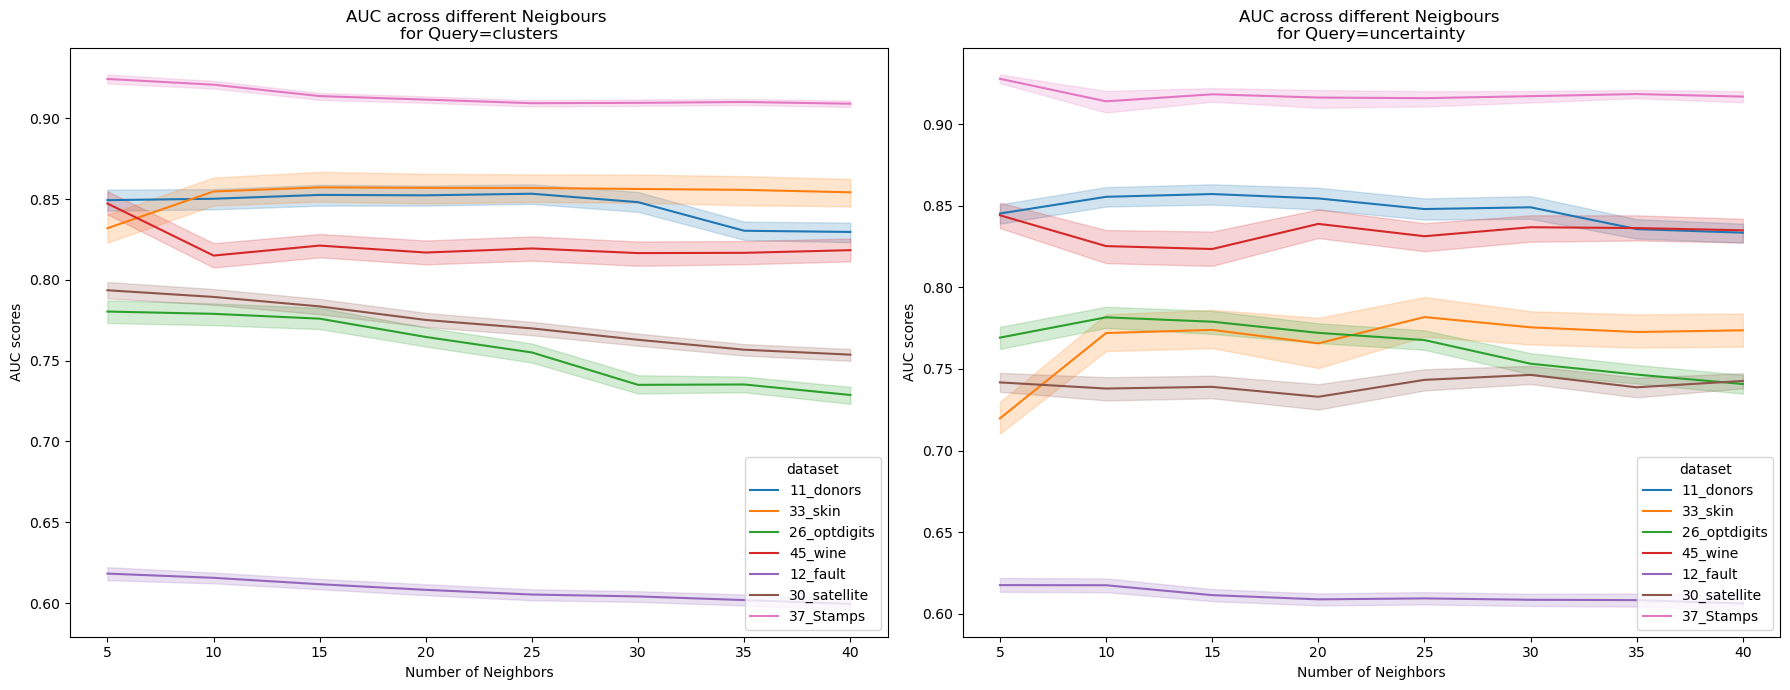

In [44]:
queries = iforest.query_strategy.unique()
fig, axes = plt.subplots(1, len(queries), figsize=(18, 7))
for i, each_query in enumerate(queries):
    each_iforest_data = iforest[iforest.query_strategy == each_query].reset_index(drop=True)
    sns.lineplot(
        x ="n_neighbors",
        y ="roc_auc",
        data= each_iforest_data,
        hue = "dataset",
        ax=axes[i]
    )
    axes[i].set_title(f"AUC across different Neigbours \nfor Query={each_query}")
    axes[i].set_xlabel("Number of Neighbors")
    axes[i].set_ylabel("AUC scores")
plt.tight_layout()
plt.show()




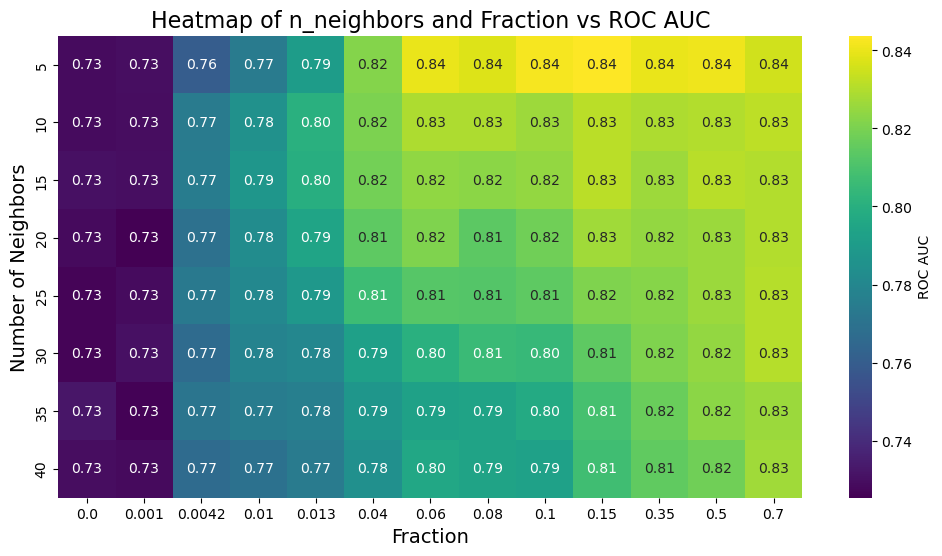

In [41]:
# as per fraction
"""
Checking for only clustering one
"""
clustering_information = iforest[iforest.query_strategy == "clusters"].reset_index(drop=True)
plt.figure(figsize=(12, 6))
pivot_roc_auc_neighbors = clustering_information.pivot_table(values='roc_auc', index='n_neighbors', columns='fraction', aggfunc='mean')
sns.heatmap(pivot_roc_auc_neighbors, cmap='viridis', annot=True, fmt=".2f", cbar_kws={'label': 'ROC AUC'})
plt.title('Heatmap of n_neighbors and Fraction vs ROC AUC', fontsize=16)
plt.xlabel('Fraction', fontsize=14)
plt.ylabel('Number of Neighbors', fontsize=14)
plt.show()

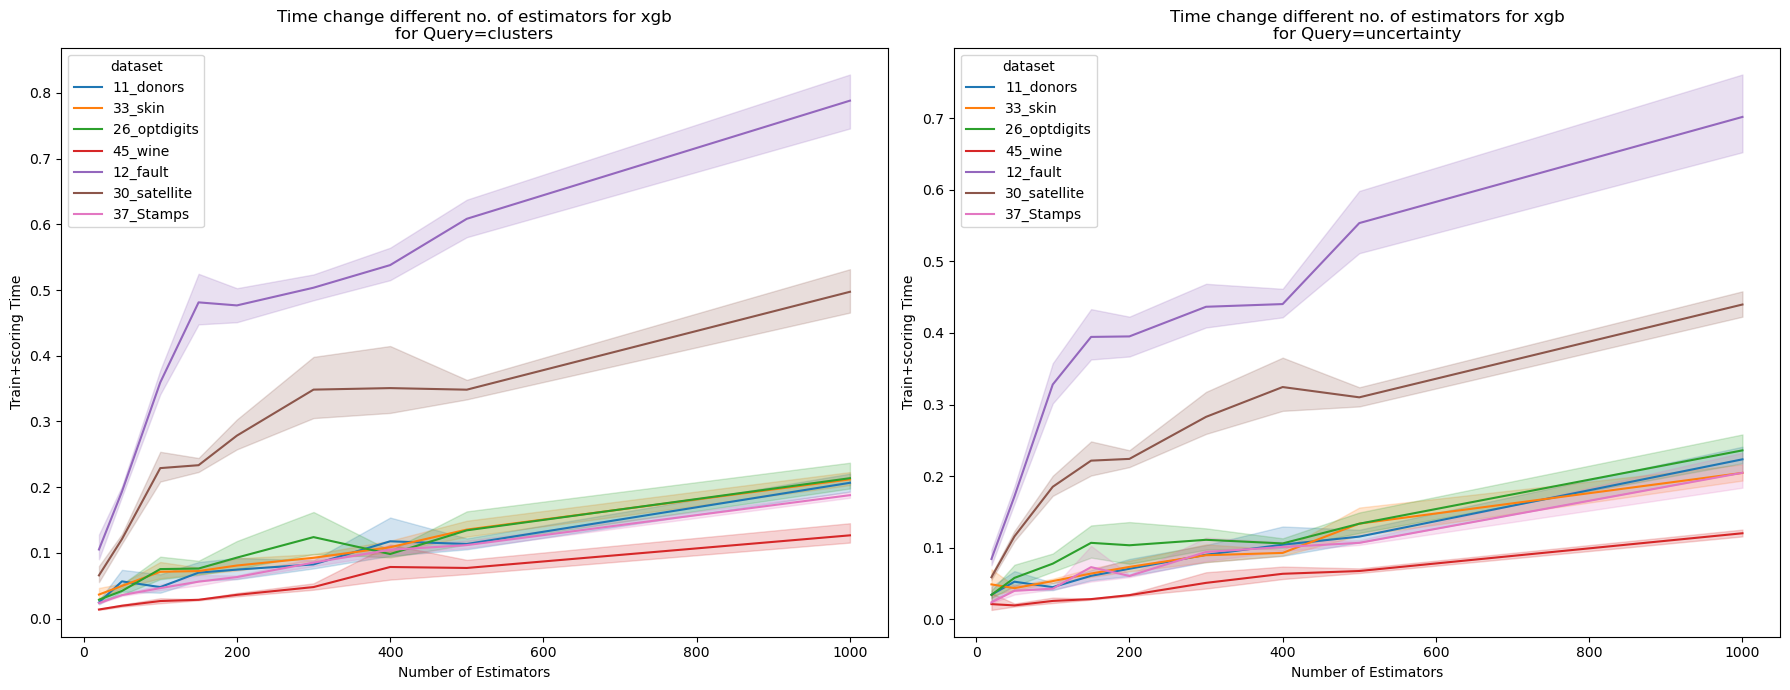

In [42]:
# for the case of gboost

queries = iforest.query_strategy.unique()
fig, axes = plt.subplots(1, len(queries), figsize=(18, 7))
for i, each_query in enumerate(queries):
    each_xgb_data = xgb[xgb.query_strategy == each_query].reset_index(drop=True)
    sns.lineplot(
        x="estimators",
        y="time",
        data=each_xgb_data,
        hue="dataset",
        ax=axes[i]  
    )
    axes[i].set_title(f"Time change different no. of estimators for xgb\nfor Query={each_query}")
    axes[i].set_xlabel("Number of Estimators")
    axes[i].set_ylabel("Train+scoring Time")
plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'AUC across different no. of estimators for xgb for Clustering')

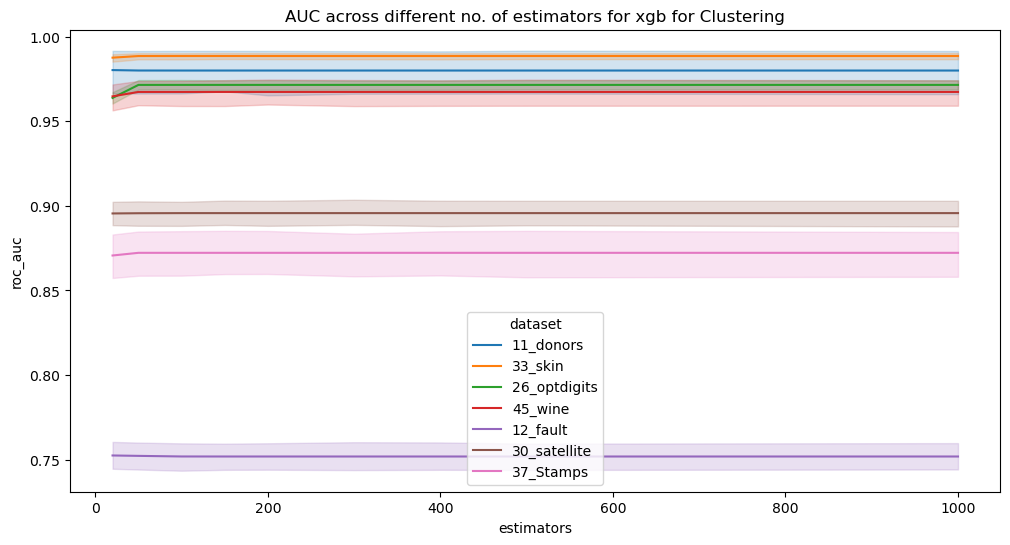

In [46]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    x ="estimators",
    y ="roc_auc",
    data= xgb[xgb.query_strategy=="clusters"],
    hue = "dataset",
)

plt.title("AUC across different no. of estimators for xgb for Clustering")




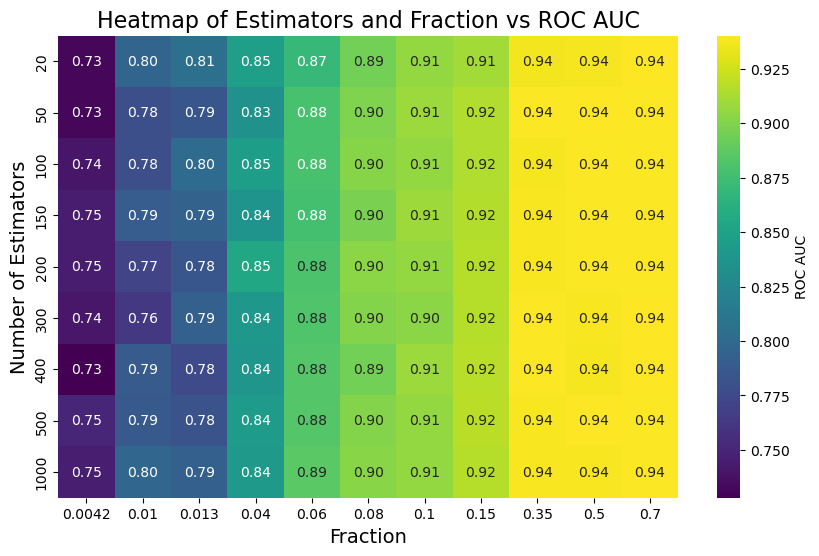

In [47]:
pivot_roc_auc_estimators = xgb.pivot_table(values='roc_auc', index='estimators', columns='fraction', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_roc_auc_estimators, cmap='viridis', annot=True, fmt=".2f", cbar_kws={'label': 'ROC AUC'})
plt.title('Heatmap of Estimators and Fraction vs ROC AUC', fontsize=16)
plt.xlabel('Fraction', fontsize=14)
plt.ylabel('Number of Estimators', fontsize=14)
plt.show()

<Axes: xlabel='num_labels', ylabel='roc_auc'>

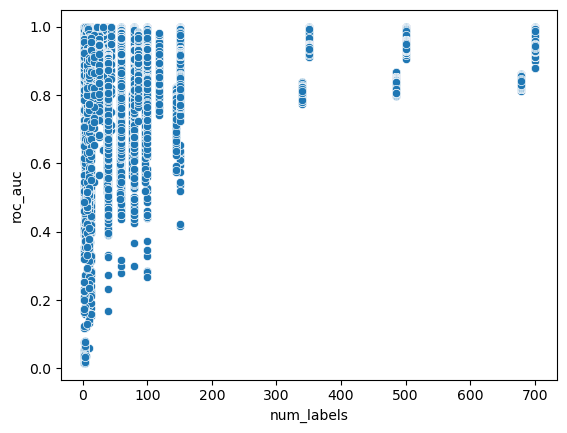

In [48]:
sns.scatterplot(
    y = "roc_auc",
    x= "num_labels",
    data = xgb,
    # hue = "dataset"
)